# Quadratic Unconstrained Binary Optimization

見 [PennyLane: Quadratic Unconstrained Binary Optimization](https://pennylane.ai/qml/demos/tutorial_QUBO).


## Combinatorial Optimization Problems

In [1]:
items_values = {"⚽️": 8, "💻": 47, "📸": 10, "📚":  5, "🎸": 16}
items_weight = {"⚽️": 3, "💻": 11, "📸": 14, "📚": 19, "🎸":  5}
maximum_weight = 26

In [2]:
import numpy as np


values_list = list(items_values.values())
weights_list = list(items_weight.values())


def sum_weight(bitstring, items_weight):
    weight = 0
    for n, i in enumerate(items_weight):
        if bitstring[n] == "1":
            weight += i
    return weight


def sum_values(bitstring, items_value):
    value = 0
    for n, i in enumerate(items_value):
        if bitstring[n] == "1":
            value += i
    return value

items = list(items_values.keys())
n_items = len(items)
combinations = {}
max_value = 0
for case_i in range(2**n_items):  # all possible options
    combinations[case_i] = {}
    bitstring = np.binary_repr(
        case_i, n_items
    )  # bitstring representation of a possible combination, e.g, "01100" in our problem means bringing (-💻📸--)
    combinations[case_i]["items"] = [items[n] for n, i in enumerate(bitstring) if i == "1"]
    combinations[case_i]["value"] = sum_values(bitstring, values_list)
    combinations[case_i]["weight"] = sum_values(bitstring, weights_list)
    # save the information of the optimal solution (the one that maximizes the value while respecting the maximum weight)
    if (
        combinations[case_i]["value"] > max_value
        and combinations[case_i]["weight"] <= maximum_weight
    ):
        max_value = combinations[case_i]["value"]
        optimal_solution = {
            "items": combinations[case_i]["items"],
            "value": combinations[case_i]["value"],
            "weight": combinations[case_i]["weight"],
        }


print(
    f"The best combination is {optimal_solution['items']} with a total value: {optimal_solution['value']} and total weight {optimal_solution['weight']} "
)

The best combination is ['⚽️', '💻', '🎸'] with a total value: 71 and total weight 19 


In [3]:
Q = -np.diag(values_list)  # Matrix Q for the problem above.
x_opt = np.array(
    [[1 if i in optimal_solution["items"] else 0] for i in items_values.keys()]
)  # Optimal solution.

opt_str = "".join(str(i[0]) for i in x_opt)
min_cost = (x_opt.T @ Q @ x_opt)[0, 0]  # using Equation 3 above
print(f"Q={Q}")
print(f"The minimum cost is  {min_cost}")


Q=[[ -8   0   0   0   0]
 [  0 -47   0   0   0]
 [  0   0 -10   0   0]
 [  0   0   0  -5   0]
 [  0   0   0   0 -16]]
The minimum cost is  -71


### 轉成 QUBO form

假設 $Q\in\mathbb{R}^{n\times n}$ 是個 "upper triangular square matrix", 我們要轉成 QUBO form:
$$
C(\mathbf{x})=\mathbf{x}^T Q \mathbf{x} \\ = \sum_{i, j=1}^n Q_{ij} x_i x_j \\
=\sum_i^n Q_{ii}x_i + \sum_i^n\sum_{j=i+1}^n Q_{ij}x_i x_j
$$

* 因為
$$
\left(\sum_i \omega_i x_i\right)^2 \\
= \left(\sum_i \omega_i x_i\right) \left(\sum_j \omega_j x_j\right) \\
= \left(\sum_i \omega_i^2 x_i^2 \right) + \left( \sum_{i\neq j} \omega_i\omega_j x_i x_j \right) \\
= \left(\sum_i \omega_i^2 x_i^2 \right) + 2 \left( \sum_{i}\sum_{j = i+1} \omega_i\omega_j x_i x_j\right)
$$

* 所以
$$
C(\mathbf{x}, \mathbf{\omega}) = -\sum_i v_i x_i + \lambda \left(\sum_i \omega_i x_i-W\right)^2 \\
=-\sum_i v_i x_i - \lambda \sum_i \omega_i \left(2W -\omega_i\right)x_i + \left(\sum_i\sum_{j=i+1}2\lambda \omega_i \omega_j x_i x_j\right) + \lambda W^2 \\
= \left( \sum_i \underbrace{\left(-vi + \lambda \omega_i \left(\omega_i - 2W\right)\right)}_{Q_{ii}} x_i \right) + \left(\sum_i\sum_{j=i+1}\underbrace{\left(2\lambda \omega_i \omega_j\right)}_{Q_{ij}} x_i x_j\right) + \underbrace{\lambda W^2}_{\text{定值}}
$$


In [4]:
N = round(np.ceil(np.log2(maximum_weight)))  # number of slack variables
weights = list(items_weight.values()) + [2**k for k in range(N)]

QT = np.pad(Q, ((0, N), (0, N)))  # adding the extra slack variables at the end of the Q matrix
n_qubits = len(QT)
lambd = 2  # We choose a lambda parameter enough large for the constraint to always be fulfilled
# Adding the terms for the penalty term
for i in range(len(QT)):
    QT[i, i] += lambd * weights[i] * (weights[i] - 2 * maximum_weight)  # Eq. 10
    for j in range(i + 1, len(QT)):
        QT[i, j] += 2 * lambd * weights[i] * weights[j]  # Eq. 9
offset = lambd * maximum_weight**2
print(f"Q={QT}")
# optimal string slack string
slack_string = np.binary_repr(maximum_weight - optimal_solution["weight"], N)[::-1]
print(f"slack_string={slack_string}")
x_opt_slack = np.concatenate(
    (x_opt, np.array([[int(i)] for i in slack_string]))
)  # combining the optimal string and slack string
opt_str_slack = "".join(str(i[0]) for i in x_opt_slack)
print(f"opt_str_slack={opt_str_slack}")
cost = (x_opt_slack.T @ QT @ x_opt_slack)[0, 0] + offset  # Optimal cost using equation 3
print(f"Cost:{cost}")

# At this point, we have encoded the problem in a format that we can use to solve it on quantum
# computers. Now it only remains to solve it using quantum algorithms!

Q=[[ -302   132   168   228    60    12    24    48    96   192]
 [    0  -949   616   836   220    44    88   176   352   704]
 [    0     0 -1074  1064   280    56   112   224   448   896]
 [    0     0     0 -1259   380    76   152   304   608  1216]
 [    0     0     0     0  -486    20    40    80   160   320]
 [    0     0     0     0     0  -102     8    16    32    64]
 [    0     0     0     0     0     0  -200    32    64   128]
 [    0     0     0     0     0     0     0  -384   128   256]
 [    0     0     0     0     0     0     0     0  -704   512]
 [    0     0     0     0     0     0     0     0     0 -1152]]
slack_string=11100
opt_str_slack=1100111100
Cost:-71


### QAOA

In [8]:
# -----------------------------   QAOA circuit ------------------------------------
from collections import defaultdict
import pennylane as qp

shots = 5000  # Number of samples used
dev = qp.device("default.qubit")


@qp.set_shots(shots)
@qp.qnode(dev)
def qaoa_circuit(gammas, betas, h, J, num_qubits):
    wmax = max(
        np.max(np.abs(list(h.values()))), np.max(np.abs(list(h.values())))
    )  # Normalizing the Hamiltonian is a good idea
    p = len(gammas)
    # Apply the initial layer of Hadamard gates to all qubits
    for i in range(num_qubits):
        qp.Hadamard(wires=i)
    # repeat p layers the circuit shown in Fig. 1
    for layer in range(p):
        # ---------- COST HAMILTONIAN ----------
        for ki, v in h.items():  # single-qubit terms
            qp.RZ(2 * gammas[layer] * v / wmax, wires=ki[0])
        for kij, vij in J.items():  # two-qubit terms
            qp.CNOT(wires=[kij[0], kij[1]])
            qp.RZ(2 * gammas[layer] * vij / wmax, wires=kij[1])
            qp.CNOT(wires=[kij[0], kij[1]])
        # ---------- MIXER HAMILTONIAN ----------
        for i in range(num_qubits):
            qp.RX(-2 * betas[layer], wires=i)
    return qp.sample()


def samples_dict(samples, n_items):
    """Just sorting the outputs in a dictionary"""
    results = defaultdict(int)
    for sample in samples:
        results["".join(str(i) for i in sample)[:n_items]] += 1
    return results

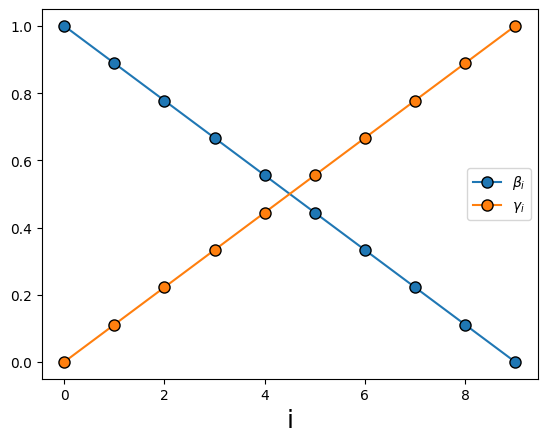

In [6]:
import matplotlib.pyplot as plt
# Annealing schedule for QAOA
betas = np.linspace(0, 1, 10)[::-1]  # Parameters for the mixer Hamiltonian
gammas = np.linspace(0, 1, 10)  # Parameters for the cost Hamiltonian (Our Knapsack problem)

fig, ax = plt.subplots()
ax.plot(betas, label=r"$\beta_i$", marker="o", markersize=8, markeredgecolor="black")
ax.plot(gammas, label=r"$\gamma_i$", marker="o", markersize=8, markeredgecolor="black")
ax.set_xlabel("i", fontsize=18)
ax.legend()
fig.show()

* 因為 $x_i=\frac{1-z_i}{2}$ 要轉成 QAOA:
$$
H_c(\mathbf{z})=\sum_i^n\sum_{j=i+1}^n J_{ij} z_i z_j + \sum_{i=1}^n h_i z_i + O
$$

  * 其中:
    * $O$: 是 offset

* 所以 QUBO form:
$$
C(\mathbf{x})=\mathbf{x}^T Q \mathbf{x} \\ = \sum_{i, j=1}^n Q_{ij} x_i x_j \\
=\sum_i^n Q_{ii}x_i + \sum_i^n\sum_{j=i+1}^n Q_{ij}x_i x_j \\
=\sum_i^n Q_{ii}\frac{1-z_i}{2} + \sum_i^n\sum_{j=i+1}^n Q_{ij}\frac{\left(1-z_i\right)\left(1-z_j\right)}{4} \\
=\sum_i^n\frac{Q_{ii}}{2} -\sum_i^n\frac{Q_{ii}}{2}z_i+\sum_i^n\sum_{j=i+1}^n Q_{ij}\frac{1-z_i-z_j+z_i z_j}{4}
$$


In [7]:
def from_Q_to_Ising(Q, offset):
    """Convert the matrix Q of Eq.3 into Eq.13 elements J and h"""
    n_qubits = len(Q)  # Get the number of qubits (variables) in the QUBO matrix
    # Create default dictionaries to store h and pairwise interactions J
    h = defaultdict(int)
    J = defaultdict(int)

    # Loop over each qubit (variable) in the QUBO matrix
    for i in range(n_qubits):
        # Update the magnetic field for qubit i based on its diagonal element in Q
        h[(i,)] -= Q[i, i] / 2
        # Update the offset based on the diagonal element in Q
        offset += Q[i, i] / 2
        # Loop over other qubits (variables) to calculate pairwise interactions
        for j in range(i + 1, n_qubits):
            # Update the pairwise interaction strength (J) between qubits i and j
            J[(i, j)] += Q[i, j] / 4
            # Update the magnetic fields for qubits i and j based on their interactions in Q
            h[(i,)] -= Q[i, j] / 4
            h[(j,)] -= Q[i, j] / 4
            # Update the offset based on the interaction strength between qubits i and j
            offset += Q[i, j] / 4
    # Return the magnetic fields, pairwise interactions, and the updated offset
    return h, J, offset


def energy_Ising(z, h, J, offset):
    """
    Calculate the energy of an Ising model given spin configurations.

    Parameters:
    - z: A dictionary representing the spin configurations for each qubit.
    - h: A dictionary representing the magnetic fields for each qubit.
    - J: A dictionary representing the pairwise interactions between qubits.
    - offset: An offset value.

    Returns:
    - energy: The total energy of the Ising model.
    """
    if isinstance(z, str):
        z = [(1 if int(i) == 0 else -1) for i in z]
    # Initialize the energy with the offset term
    energy = offset
    # Loop over the magnetic fields (h) for each qubit and update the energy
    for k, v in h.items():
        energy += v * z[k[0]]
    # Loop over the pairwise interactions (J) between qubits and update the energy
    for k, v in J.items():
        energy += v * z[k[0]] * z[k[1]]
    # Return the total energy of the Ising model
    return energy


# Our previous example should give us the same result
z_exp = [
    (1 if i == 0 else -1) for i in x_opt_slack
]  # Converting the optimal solution from (0,1) to (1, -1)
h, J, zoffset = from_Q_to_Ising(QT, offset)  # Eq.13 for our problem
energy = energy_Ising(
    z_exp, h, J, zoffset
)  # Caluclating the energy (Should be the same that for the QUBO)
print(f"Minimum energy:{energy}")

samples_slack = samples_dict(qaoa_circuit(gammas, betas, h, J, num_qubits=len(QT)), n_qubits)
values_slack = {
    sum_values(sample_i, values_list): count
    for sample_i, count in samples_slack.items()
    if sum_weight(sample_i, weights_list) <= maximum_weight
}  # saving only the solutions that fulfill the constraint
print(
    f"The number of optimal solutions using slack variables is {samples_slack[opt_str_slack]} out of {shots}"
)

Minimum energy:-71.0
The number of optimal solutions using slack variables is 18 out of 5000


顯示 QAOA circuit

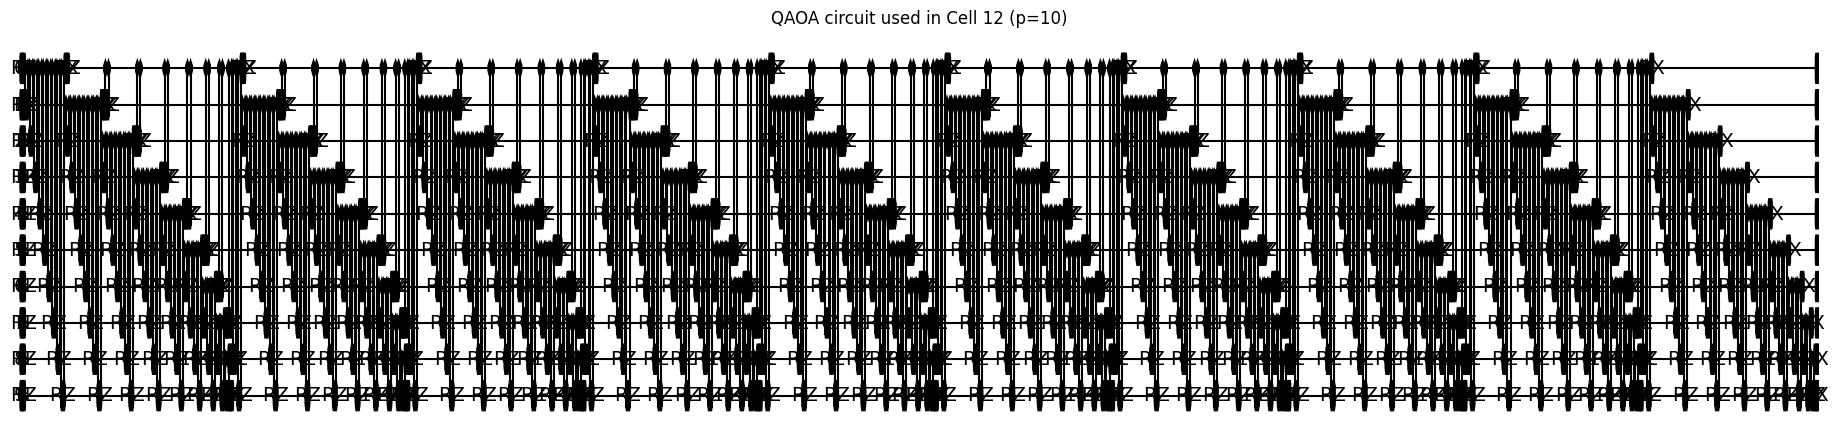

In [11]:
# Display the same QAOA circuit used in Cell 12
fig, ax = qp.draw_mpl(qaoa_circuit)(gammas, betas, h, J, num_qubits=len(QT))
fig.set_size_inches(18, 4)
ax.set_title(f"QAOA circuit used in Cell 12 (p={len(gammas)})")
plt.show()

In [13]:
# Print a 純文字 (ASCII) diagram of the same QAOA circuit
print(qp.draw(qaoa_circuit)(gammas, betas, h, J, num_qubits=len(QT)))

0: ──H──RZ(-0.00)─╭●───────────╭●─╭●───────────╭●─╭●───────────╭●─╭●───────────╭●─╭●────────── ···
1: ──H──RZ(-0.00)─╰X──RZ(0.00)─╰X─│────────────│──│────────────│──│────────────│──│─────────── ···
2: ──H──RZ(-0.00)─────────────────╰X──RZ(0.00)─╰X─│────────────│──│────────────│──│─────────── ···
3: ──H──RZ(-0.00)─────────────────────────────────╰X──RZ(0.00)─╰X─│────────────│──│─────────── ···
4: ──H──RZ(-0.00)─────────────────────────────────────────────────╰X──RZ(0.00)─╰X─│─────────── ···
5: ──H──RZ(-0.00)─────────────────────────────────────────────────────────────────╰X──RZ(0.00) ···
6: ──H──RZ(-0.00)───────────────────────────────────────────────────────────────────────────── ···
7: ──H──RZ(-0.00)───────────────────────────────────────────────────────────────────────────── ···
8: ──H──RZ(-0.00)───────────────────────────────────────────────────────────────────────────── ···
9: ──H──RZ(-0.00)───────────────────────────────────────────────────────────────────────────── ···

0: ··· ─╭